In [1]:
import numpy as np
import datetime
from read_meteorradar_mpd import read_meteorradar_mpd
from fit_meteorwinds_comparison25 import fit_meteorwinds_comparison
import matplotlib.pyplot as plt

../Data/mp20230105.riogrande.mpd
Out of  17917  there are  12374  valid echoes, and pure ones  10809
Out of  20030  there are  12440  valid echoes, and pure ones  11091
 Valid data entries:  10857
Wind:  -36.492001904018394 -10.873353330448921 -0.8342335083764999


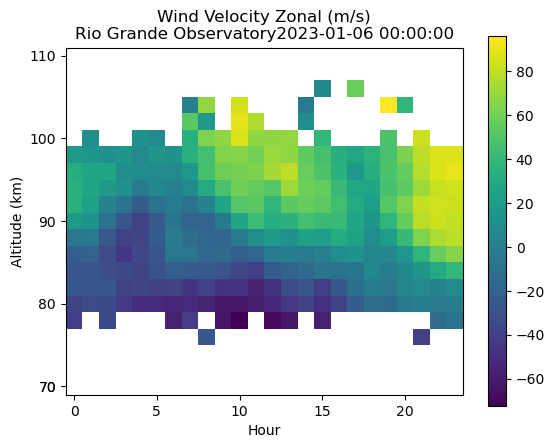

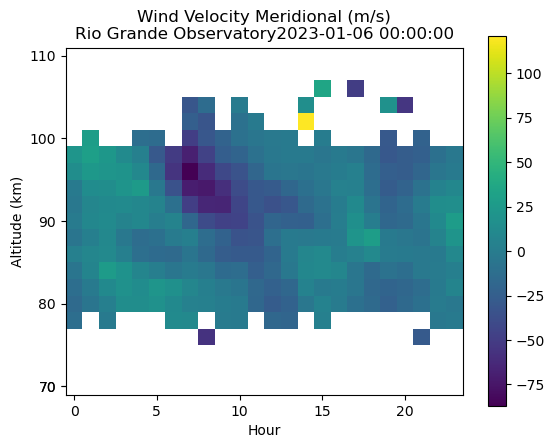

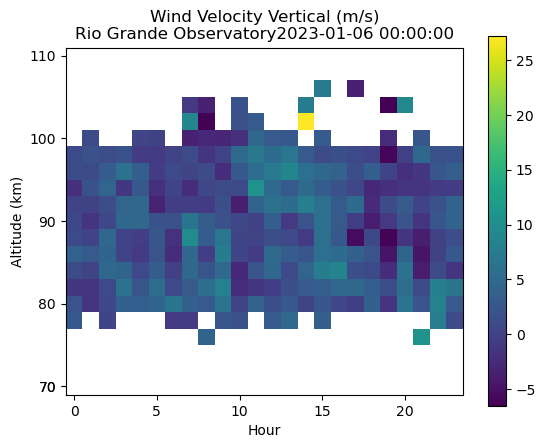

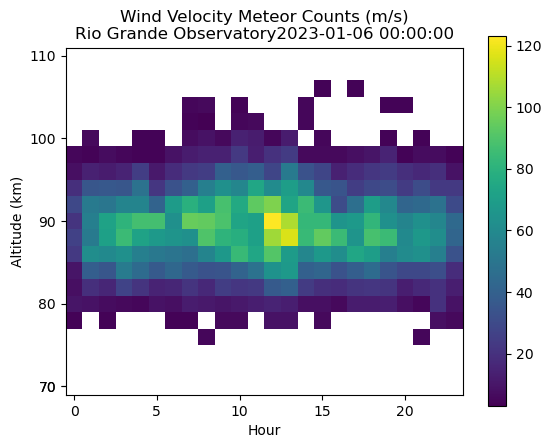

Saving data for 20230106
../Data/mp20230106.riogrande.mpd
Out of  17917  there are  12374  valid echoes, and pure ones  10809
Out of  20030  there are  12440  valid echoes, and pure ones  11091
Out of  18467  there are  12346  valid echoes, and pure ones  10792
 Valid data entries:  11246
Wind:  18.67550768782178 51.02914097313221 5.386593216286082


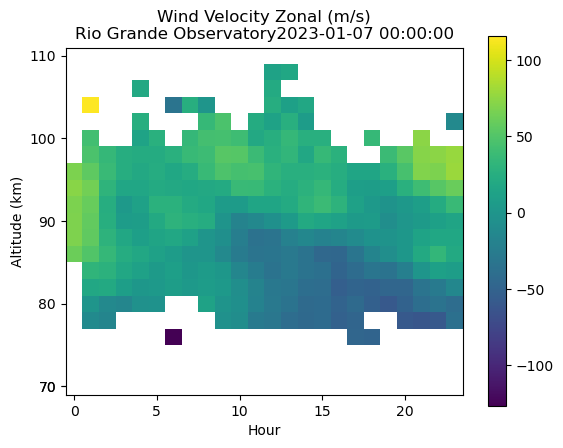

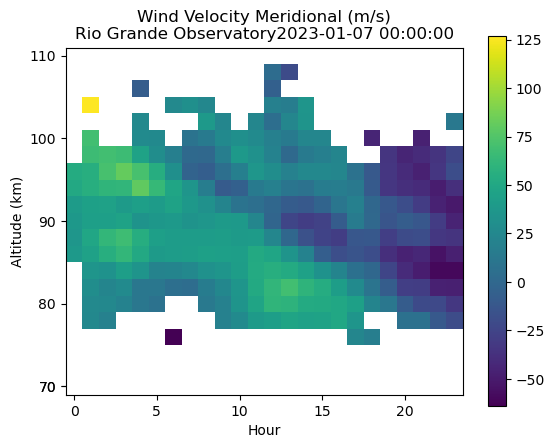

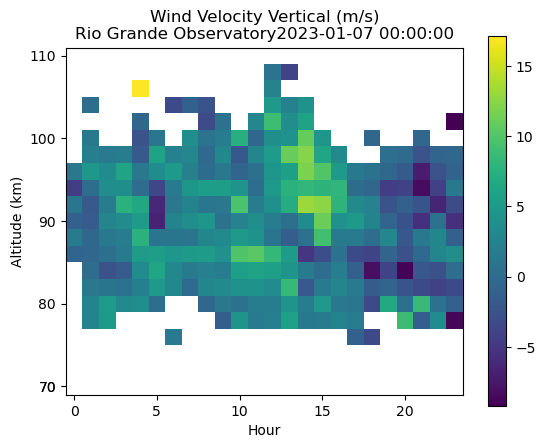

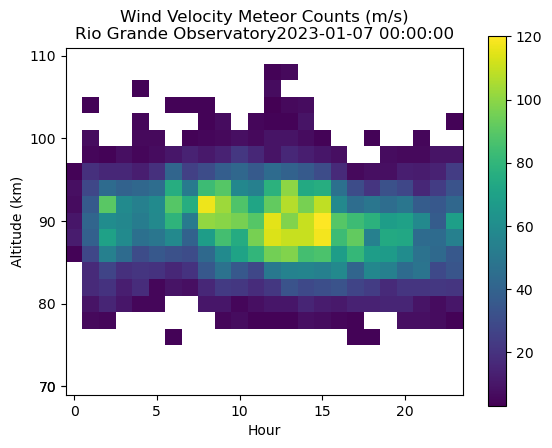

Saving data for 20230107
../Data/mp20230107.riogrande.mpd
Out of  20030  there are  12440  valid echoes, and pure ones  11091
Out of  18467  there are  12346  valid echoes, and pure ones  10792
Out of  12729  there are  9303  valid echoes, and pure ones  8103
 Valid data entries:  11044
Wind:  -9.860763151609252 16.203622963235084 0.5406773501654011


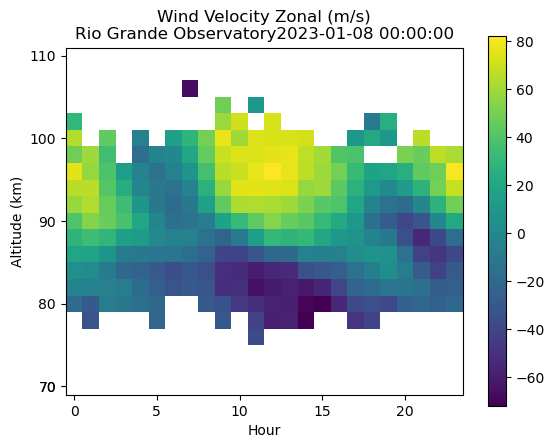

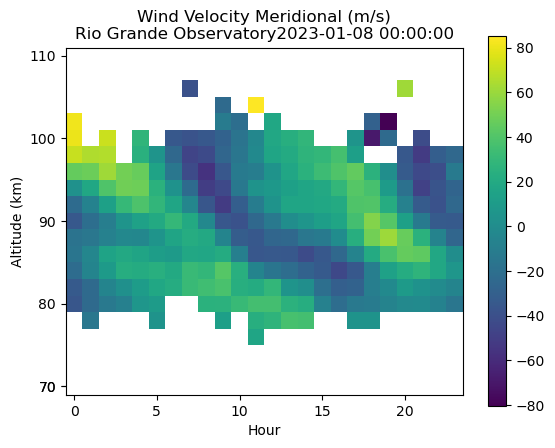

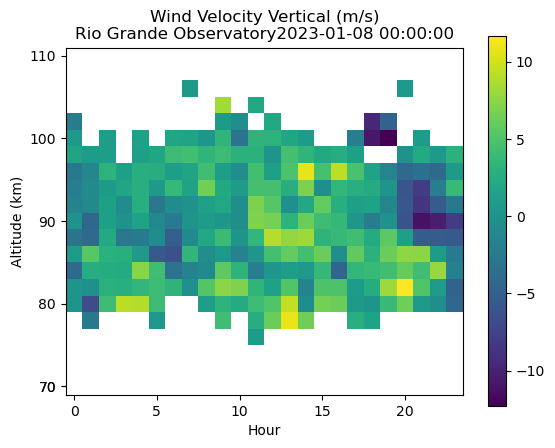

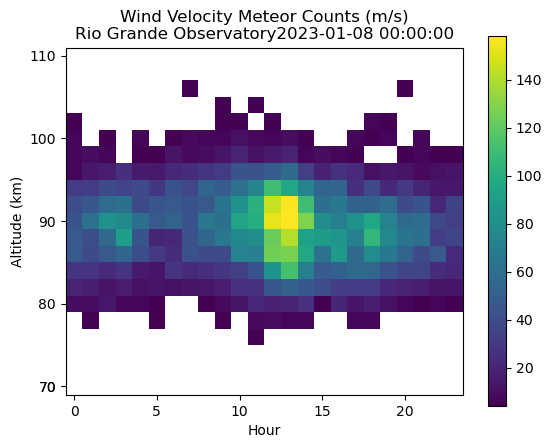

Saving data for 20230108
../Data/mp20230108.riogrande.mpd
Out of  18467  there are  12346  valid echoes, and pure ones  10792
Out of  12729  there are  9303  valid echoes, and pure ones  8103
Out of  16363  there are  11385  valid echoes, and pure ones  9995
 Valid data entries:  8387
Wind:  -7.1375949216489625 -1.895594949154945 6.34130676948166


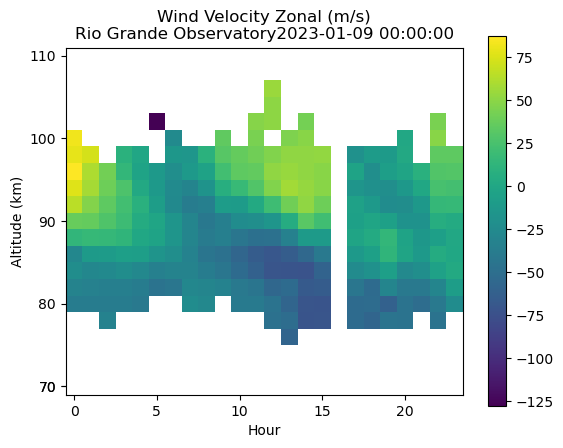

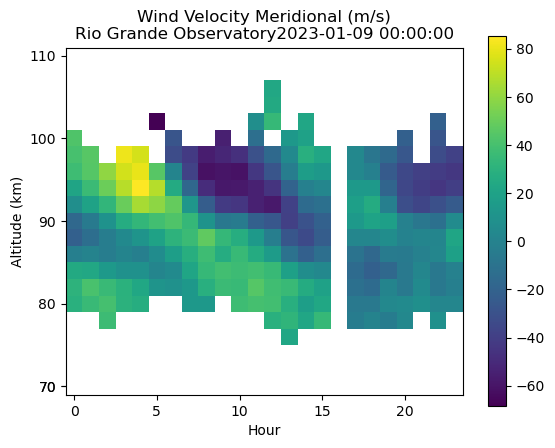

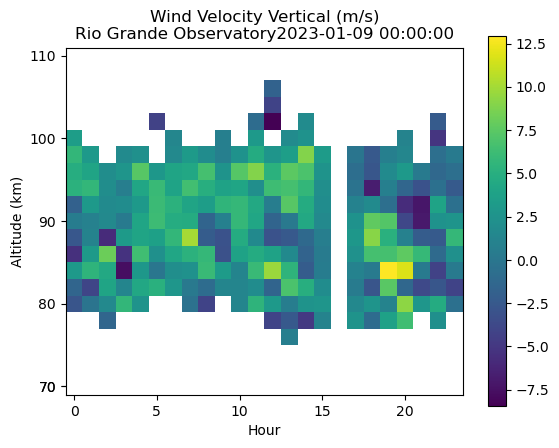

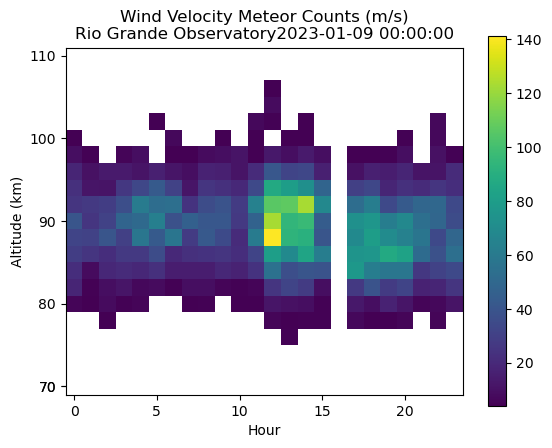

Saving data for 20230109
../Data/mp20230109.riogrande.mpd
Out of  12729  there are  9303  valid echoes, and pure ones  8103
Out of  16363  there are  11385  valid echoes, and pure ones  9995
 Valid data entries:  10165
Wind:  -13.979202803215069 22.694979792056138 -6.432150137410004


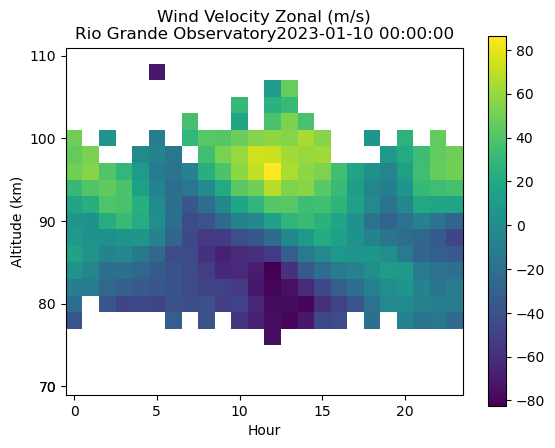

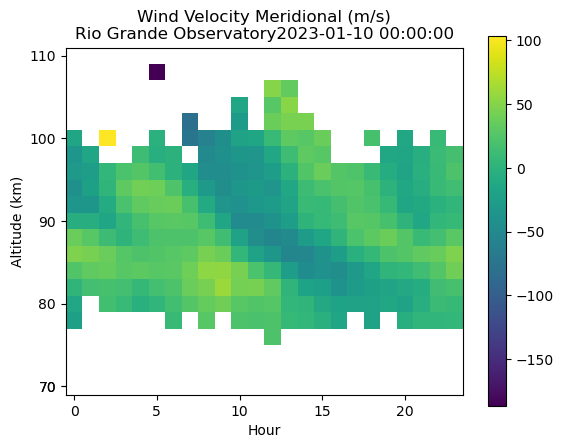

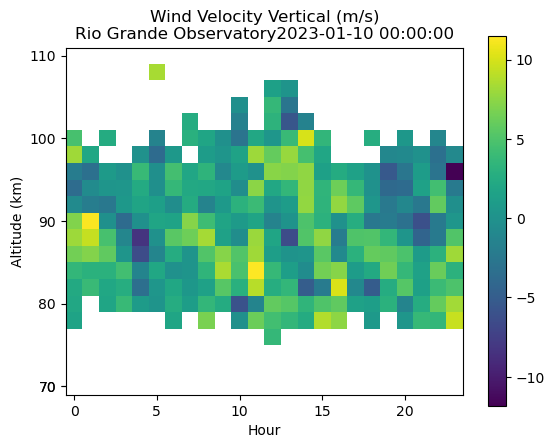

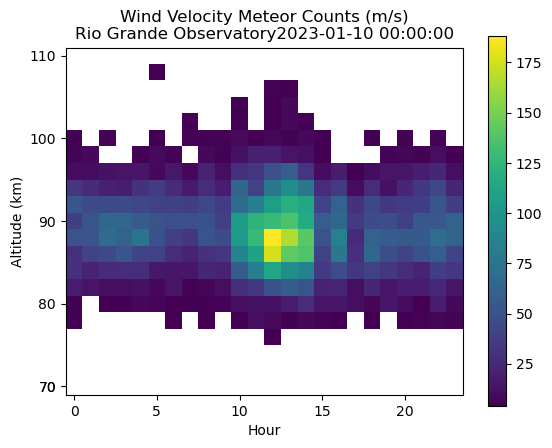

Saving data for 20230110


In [3]:
def filtering(data,ThetaMax):
    # Data entries
    #     0     1    2  3    4    5     6    7      8     9       10      11   12  13  14    15
    # DateTime,File,Rge,Ht,Vrad,delVr,Theta,Phi0,Ambig,Delphase,ant_pair,IREX,amax,Tau,vmet,snrdb
    total = len(data)
    valid1, valid2, vrad_med = 0,0,0.
    dat,dat2 = [],[]
    for a in data:
        if (a[8]!=1)|(a[2]>400.)|(a[6]>ThetaMax)|(a[15]<5.)|(np.abs(a[4])>110.): continue
        #dd = (np.cos(np.radians(a[7]))*np.sin(np.radians(a[6])))**2.+ \
        #    (np.sin(np.radians(a[7]))*np.cos(np.radians(a[6])))**2.
        #if dd>1.: continue
        dat.append(a)
        valid1+=1
        vrad_med+=a[4]
  
    if valid1==0: return dat2
    vrad_med=vrad_med/float(valid1)
    vrad_thres=110.0
    if np.abs(vrad_med)<=5.:
        vrad_thres=110.0
    elif (np.abs(vrad_med)>5.)&(np.abs(vrad_med)<10.):
        vrad_thres=90.0
    else:
        vrad_thres=80.0

    jump = 0
    ###  Removing multple counts from a (potential) single meteor echo ###
    for j,a in enumerate(dat):
        if j==valid1-1:
            dat2.append(dat[j])
        else:
            if jump==j:
                i = 1
                while (np.abs((dat[j][0]-dat[j+i][0]).total_seconds())<=0.008)&  \
                      (np.abs(dat[j][7]-dat[j+i][7])<=2.)& \
                      (np.abs(dat[j][6]-dat[j+i][6])<=2.):
                    i+=1
                    if (i+j)>=len(dat): break
                jmin,jmax=j,j+i
                d=jmin
                ivalue=j
                if i>0:
                    for kk in range(jmin,jmax):
                        if dat[d][12]<dat[kk][12]:
                            d=kk
                            ivalue=kk
                jump=jmax
                valid2+=1
                dat2.append(dat[ivalue])
   
    print('Out of ',total,' there are ',len(dat),' valid echoes, and pure ones ',len(dat2))
    return dat2

dt0=datetime.datetime(2023,1,6,0)
dt1=datetime.datetime(2023,1,10,0)

dt=dt0
bmin = 69 #km
bmax = 109 #km
binsize = 2 #km
ThetaMin = 0. #minimum zenith angle to consider
ThetaMax = 65. #maximum zenith angle to consider
# remove times during which wind determination might not be trusted by using fit_meteorwinds_comparison.
# In that code, no wind is determined when too many meteors are determined outside the 70 to 100 km range.
begin_day = 0.
sta = 'riogrande'
#sta = 'rothera'
#sta = 'leipzig'

def plotWinds(Vs,D,dt):
    fig, ax1 = plt.subplots()
    La = 20
    ticks = [70+2*i for i in [0,0,La//4, La//2, 3*La//4,La]]
    im = ax1.imshow(Vs.T, aspect=1) #,vmin=-20, vmax=20
    plt.colorbar(im)
    ax1.invert_yaxis()
    ax1.set_title(f"Wind Velocity {D} (m/s)\nRio Grande Observatory{dt}")
    ax1.set_yticks([0,0,La//4, La//2, 3*La//4,La],ticks)
    ax1.set_xlabel("Hour")
    ax1.set_ylabel("Altitude (km)")
    plt.show()

while dt<=dt1:
    print('../Data/mp'+(dt-datetime.timedelta(days=1)).strftime("%Y%m%d")+ \
            '.'+sta+'.mpd')
    data1 = read_meteorradar_mpd('../Data/mp'+(dt-datetime.timedelta(days=1)).strftime("%Y%m%d")+ \
            '.'+sta+'.mpd',verbose=0)
    data2 = read_meteorradar_mpd('../Data/mp'+dt.strftime("%Y%m%d")+ \
            '.'+sta+'.mpd',verbose=0)
    data3 = read_meteorradar_mpd('../Data/mp'+(dt+datetime.timedelta(days=1)).strftime("%Y%m%d")+ \
            '.'+sta+'.mpd',verbose=0)

    dat1 = filtering(data1,ThetaMax)
    dat2 = filtering(data2,ThetaMax)
    dat3 = filtering(data3,ThetaMax)
    u, v, w, pts = fit_meteorwinds_comparison(dat1,dat2,dat3,begin_day,bmin,bmax,binsize,dt)
    Ds = ["Zonal", "Meridional", "Vertical","Meteor Counts"]
    print('Wind: ',u[4,8],v[4,8],w[4,8])
    plotWinds(u,Ds[0],dt)
    plotWinds(v,Ds[1],dt)
    plotWinds(w,Ds[2],dt)
    plotWinds(pts,Ds[3],dt)
    
    #exit()
    print('Saving data for '+dt.strftime("%Y%m%d"))
    #print((u,v,pts))
    np.save(sta[:3]+dt.strftime("%Y%m%d"),(u,v,pts))
    dt+=datetime.timedelta(days=1)